# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
   A models parameters is what makes a model linear. The coefficients are linear in a sense that the sum of the coefficients are linear.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
   The coefficient of one-hot-coding is the difference between averages per category and the intercept is the average of the category.

3. Can linear regression be used for classification? Explain why, or why not.
   No, a linear regression cannot be used for classification since a regression is used for numerical trends not categorical.

4. What are signs that your linear model is over-fitting?
   Some signs that a linear model is over-fitting is performing well in training data, but poor in testing data. Also, performing well on testing data, but poor in real-world use.

5. Clearly explain multi-colinearity using the two-stage least squares technique.
   Multi-colinearity means a predictive feature is highly correlated with another predictive feature. Explaining in the two-stage least squares technique, if one day predictor has a approximate linear variation of the other feature(s) then it is multi-colinearity.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
   Nonlinear relationship can be incorporated by applying transformation on the features such as (polynomial terms, logs, etc).

7. What is the interpretation of the slope coefficient in a linear regression?
   The slop coefficient in a linear regression is the average change between the predictors and the outcome.

8. Compare the train/test split and $k$-fold cross validation.
   Train/test split is faster, but k-fold is more in depth and iterates therefore leading to being more reliable and reduces the likelihood of the randomness of train/split of the data.

9.  How is the $k$ in $k$-fold cross validation typically selected?
    It is usually selected as 5 or 10 because it balances the amount of training data per fold.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

### Part 1

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

In [124]:
q1 = pd.read_csv("datasets/Q1_clean.csv")
q1.head()


,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [125]:
q1 = q1.rename(columns={
    "Neighbourhood ": "Neighborhood",
    "Review Scores Rating": "Review_Scores_Rating"
})

In [126]:
means = q1.groupby("Neighborhood")[["Price", "Review_Scores_Rating"]].mean()
desc = q1.groupby("Neighborhood")[["Price", "Review_Scores_Rating"]].describe()
print(means)
print(desc)

                    Price  Review_Scores_Rating
Neighborhood                                   
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750
                 Price                                                      \
                 count        mean         std   min     25%    50%    75%   
Neighborhood                                                                 
Bronx            217.0   75.276498   39.755468  10.0   50.00   60.0   90.0   
Brooklyn        8487.0  127.747378  106.038466  20.0   75.00  100.0  150.0   
Manhattan      11763.0  183.664286  170.434606  25.0  103.00  150.0  214.0   
Queens          1590.0   96.857233   61.712648  25.0   60.00   80.0  115.0   
Staten Island     96.0  146.166667  508.462029  35.0   54.75   71.0   99.0   

                       Review_Scores_Ra

In [127]:
expensive = means["Price"].idxmax()
print(expensive)

Manhattan


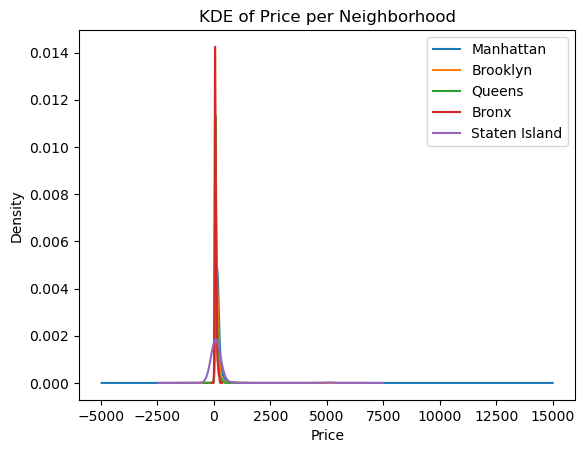

In [128]:
for n in q1["Neighborhood"].dropna().unique():
    q1.loc[q1["Neighborhood"] == n, "Price"].plot(kind="kde", label=n)
plt.title("KDE of Price per Neighborhood")
plt.xlabel("Price")
plt.legend()
plt.show()

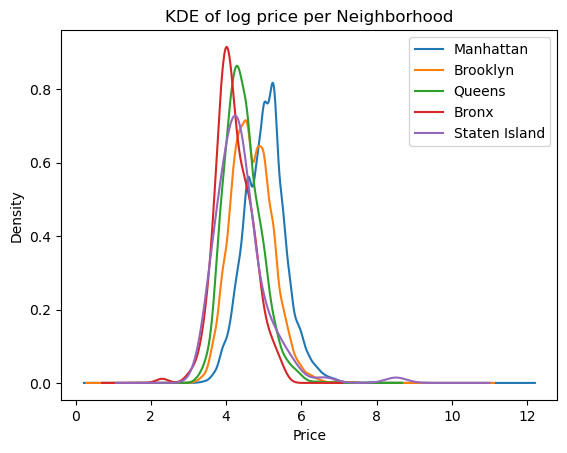

In [129]:
q1["log_price"] = np.log(q1["Price"])
for n in q1["Neighborhood"].dropna().unique():
    q1.loc[q1["Neighborhood"] == n, "log_price"].plot(kind="kde", label=n)
plt.title("KDE of log price per Neighborhood")
plt.xlabel("Price")
plt.legend()
plt.show()

### Part 2

In [130]:
X_n = pd.get_dummies(q1["Neighborhood"], drop_first=True, dtype=float)
y = q1["Price"]

model_n = LinearRegression()
model_n.fit(X_n, y)

print(f"intercept: {model_n.intercept_}")
for col, coef in zip(X_n.columns, model_n.coef_):
    print(col, ":", coef)

intercept: 75.2764976958471
Brooklyn : 52.470880647496166
Manhattan : 108.38778862567729
Queens : 21.580735008529217
Staten Island : 70.89016897079334


### Part 3

In [131]:
X_r = q1[["Review_Scores_Rating"]]

model_r = LinearRegression()
model_r.fit(X_r, y)

print(f"Intercept: {model_r.intercept_}")
print(f"Slope: {model_r.coef_[0]}")

Intercept: 60.87839065711856
Slope: 1.0208266022675305


### Part 4

In [132]:
X_nr = pd.concat([X_n, q1[["Review_Scores_Rating"]]], axis=1)
model_nr = LinearRegression()
model_nr.fit(X_nr, y)

print(f"Intercept: {model_nr.intercept_}")
for col, coef in zip(X_nr.columns, model_nr.coef_):
    print(col, ":", coef)

Intercept: -23.812561011676507
Brooklyn : 51.7042401559104
Manhattan : 108.22873656677945
Queens : 21.6945995765166
Staten Island : 71.76655213401344
Review_Scores_Rating : 1.081116483459829


### Part 5

In [133]:
dummies_full = pd.get_dummies(q1["Neighborhood"], prefix="N", drop_first=False, dtype=float)
interactions = dummies_full.mul(q1["Review_Scores_Rating"], axis=0)
interactions.columns = [col + "_x_score" for col in interactions.columns]
X_interact = pd.concat([dummies_full, interactions], axis=1)
model_interact = LinearRegression(fit_intercept=False)
model_interact.fit(X_interact, y)

for col, coef in zip(X_interact.columns, model_interact.coef_):
    print(col, ":", coef)

N_Bronx : 22.638384922087965
N_Brooklyn : 6.24539474662276
N_Manhattan : 63.95381387054277
N_Queens : 50.898086208995856
N_Staten Island : 2985.7094250428268
N_Bronx_x_score : 0.5743109493643184
N_Brooklyn_x_score : 1.315476215108774
N_Manhattan_x_score : 1.3040143939273694
N_Queens_x_score : 0.5020166039975538
N_Staten Island_x_score : -31.257436624712113


### Part 6

In [134]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
m4_scores = cross_val_score(LinearRegression(), X_nr, y, cv=cv, scoring="neg_mean_squared_error")
m5_scores = cross_val_score(LinearRegression(fit_intercept=False), X_interact, y, cv=cv, scoring="neg_mean_squared_error")

print(f"CV RMSE for regress price on neighborhood and review score: {np.mean(np.sqrt(-m4_scores))}")
print(f"CV RMSE for slope of review score of each neighborhood: {np.mean(np.sqrt(-m5_scores))}")

CV RMSE for regress price on neighborhood and review score: 139.0101861188536
CV RMSE for slope of review score of each neighborhood: 139.99908203691103


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


### Part 1

In [135]:
cars = pd.read_csv('datasets/cars_hw.csv')
print(cars)

     Unnamed: 0           Make  Make_Year   Color  Body_Type  Mileage_Run  \
0             1     Volkswagen       2017  silver      sedan        44611   
1             2        Hyundai       2016     red  crossover        20305   
2             3          Honda       2019   white        suv        29540   
3             4        Renault       2017  bronze  hatchback        35680   
4             5        Hyundai       2017  orange  hatchback        25126   
..          ...            ...        ...     ...        ...          ...   
971         972        Hyundai       2018   white      sedan        23869   
972         973        Hyundai       2019   white      sedan        14831   
973         974        Hyundai       2014  silver      sedan        52846   
974         975           Ford       2020   white  crossover        28335   
975         976  Maruti Suzuki       2018  silver  hatchback        41176   

    No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


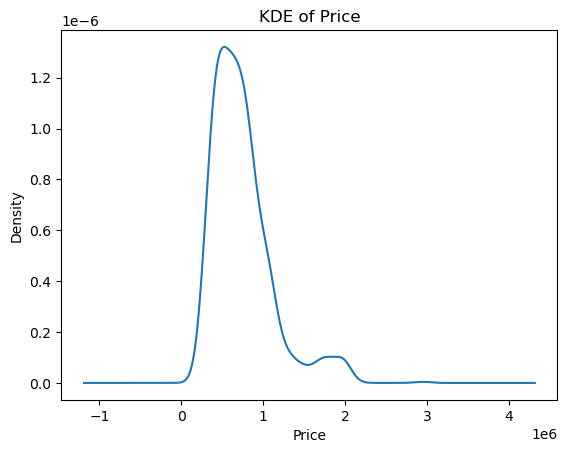

In [136]:
print(cars["Price"].describe())
cars["Price"].plot(kind="kde")
plt.title("KDE of Price")
plt.xlabel("Price")
plt.show()

In [137]:
print(cars.groupby("Body_Type")["Price"].describe())

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


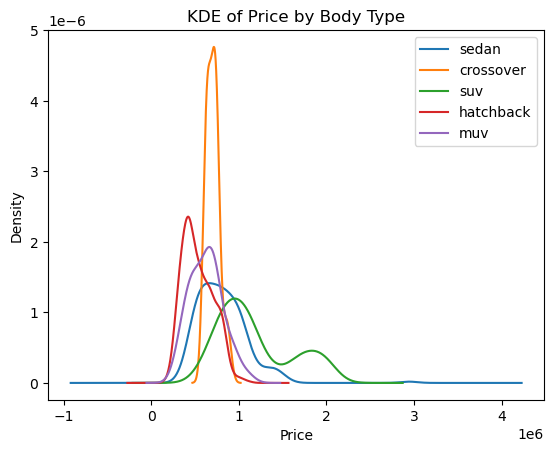

In [138]:
for b in cars["Body_Type"].dropna().unique():
    cars.loc[cars["Body_Type"] == b, "Price"].plot(kind="kde", label=b)
plt.title("KDE of Price by Body Type")
plt.xlabel("Price")
plt.legend()
plt.show()

### Part 2

In [139]:
X_seat = cars[["Seating_Capacity"]]
y = cars["Price"]

model_seat = LinearRegression()
model_seat.fit(X_seat, y)

print(f"Intercept: {model_seat.intercept_}")
print(f"Slope: {model_seat.coef_[0]}")

Intercept: 439032.0141018258
Slope: 59267.99803672191


In [140]:
X_seat_cat = pd.get_dummies(cars["Seating_Capacity"].astype(str), prefix="Seat", drop_first=True, dtype=float)

model_seat_cat = LinearRegression()
model_seat_cat.fit(X_seat_cat, y)

print(f"Intercept: {model_seat_cat.intercept_}")
for col, coef in zip(X_seat_cat.columns, model_seat_cat.coef_):
    print(col, ":", coef)

Intercept: 188000.00000001164
Seat_5 : 546483.87096773
Seat_6 : 1455999.9999999998
Seat_7 : 735948.7179487121
Seat_8 : 271799.9999999942


### Part 3

In [141]:
cars["Age"] = cars["Make_Year"].max() + 1 - cars["Make_Year"]
cv = KFold(n_splits=10, shuffle=True, random_state=42)
degrees = range(1, 11)
rmse_list = []
X_age_raw = cars[["Age"]].values
for d in degrees:
    X_poly = np.hstack([X_age_raw**i for i in range(1, d + 1)])
    scores = cross_val_score(LinearRegression(), X_poly, y,
                             cv=cv, scoring="neg_mean_squared_error")
    rmse = np.mean(np.sqrt(-scores))
    rmse_list.append(rmse)

best_degree = degrees[np.argmin(rmse_list)]
print(f"best polynomial degree: {best_degree}")
print(f"best cv rmse: {min(rmse_list)}")

best polynomial degree: 9
best cv rmse: 304139.28901720187


### Part 4

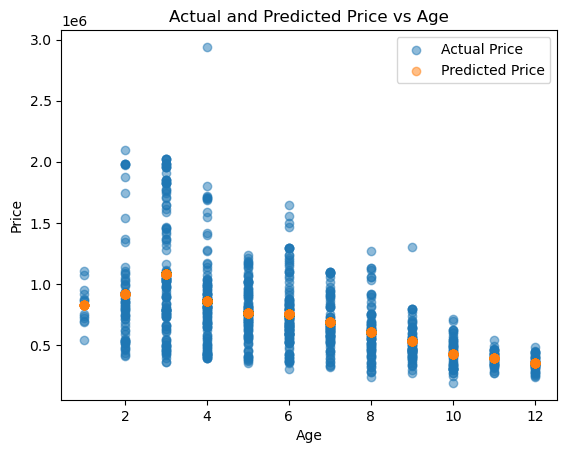

In [142]:
X_best = np.hstack([X_age_raw**i for i in range(1, best_degree + 1)])
best_model = LinearRegression()
best_model.fit(X_best, y)
yhat = best_model.predict(X_best)

plt.scatter(cars["Age"], cars["Price"], alpha=0.5, label="Actual Price")
plt.scatter(cars["Age"], yhat, alpha=0.5, label="Predicted Price")
plt.title("Actual and Predicted Price vs Age")
plt.xlabel("Age")
plt.ylabel("Price")
plt.legend()
plt.show()

The model does capture the trend, but not the nuances like expected.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


### Part 1

In [143]:
heart = pd.read_csv("datasets/heart_hw.csv")
print(heart)
heart["transplant_dummy"] = (heart["transplant"] == "treatment").astype(int)

     Unnamed: 0  age transplant  y
0             1   53    control  0
1             2   43    control  0
2             3   52    control  0
3             4   52    control  0
4             5   54    control  0
..          ...  ...        ... ..
98           99   30    control  1
99          100   48  treatment  1
100         101   40  treatment  1
101         102   48  treatment  1
102         103   33  treatment  1

[103 rows x 4 columns]


In [144]:
survival_rates = heart.groupby("transplant")["y"].mean()
print(f"survival raters by group: {survival_rates}")

survival raters by group: transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64


In [145]:
control_rate = survival_rates["control"]
treatment_rate = survival_rates["treatment"]
ATE = treatment_rate - control_rate

print(f"control survival rate group: {control_rate}")
print(f"treatment survival rate group: {treatment_rate}")
print(f"treatment - control: {ATE}")

control survival rate group: 0.11764705882352941
treatment survival rate group: 0.34782608695652173
treatment - control: 0.23017902813299232


### Part 2

In [146]:
X_t = heart[["transplant_dummy"]]
y = heart["y"]
model_t = LinearRegression()
model_t.fit(X_t, y)

print(f"intercept: {model_t.intercept_}")
print(f"coefficient: {model_t.coef_[0]}")

intercept: 0.11764705882352966
coefficient: 0.23017902813299193


### Part 3

In [147]:
X_ta = heart[["transplant_dummy", "age"]]
model_ta = LinearRegression()
model_ta.fit(X_ta, y)

print(f"intercept: {model_ta.intercept_}")
print("Coefficients:")
for col, coef in zip(X_ta.columns, model_ta.coef_):
    print(col, ":", coef)

heart["pred_ta"] = model_ta.predict(X_ta)

intercept: 0.701956972174095
Coefficients:
transplant_dummy : 0.2647016865036745
age : -0.013607217160218643


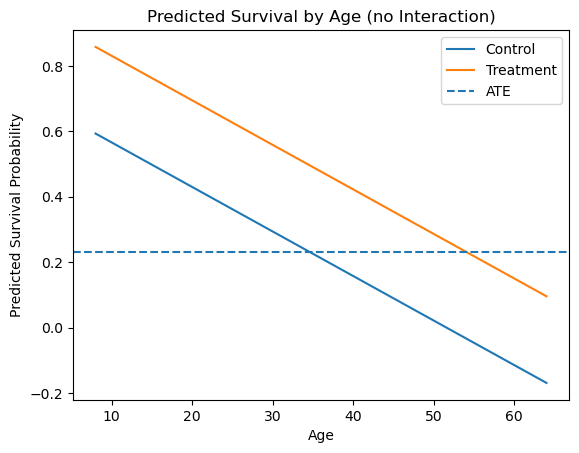

In [148]:
age_grid = np.linspace(heart["age"].min(), heart["age"].max(), 100)
pred_control = model_ta.predict(pd.DataFrame({"transplant_dummy": np.zeros_like(age_grid),"age": age_grid}))
pred_treat = model_ta.predict(pd.DataFrame({"transplant_dummy": np.ones_like(age_grid),"age": age_grid}))

plt.plot(age_grid, pred_control, label="Control")
plt.plot(age_grid, pred_treat, label="Treatment")
plt.axhline(ATE, linestyle="--", label="ATE")
plt.title("Predicted Survival by Age (no Interaction)")
plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.legend()
plt.show()

### Part 4

In [149]:
heart["transplant_age"] = heart["transplant_dummy"] * heart["age"]
X_int = heart[["transplant_dummy", "age", "transplant_age"]]
model_int = LinearRegression()
model_int.fit(X_int, y)

print(f"intercept: {model_int.intercept_}")
print("Coefficients:")
for col, coef in zip(X_int.columns, model_int.coef_):
    print(col, ":", coef)

intercept: 0.35486517529945927
Coefficients:
transplant_dummy : 0.9077513885685884
age : -0.005524257506973686
transplant_age : -0.014590638256855288


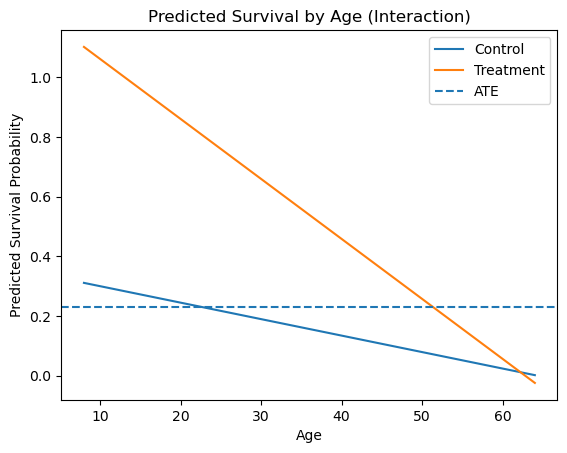

In [150]:
pred_control_int = model_int.predict(pd.DataFrame({"transplant_dummy": np.zeros_like(age_grid),"age": age_grid, "transplant_age": np.zeros_like(age_grid)}))
pred_treat_int = model_int.predict(pd.DataFrame({"transplant_dummy": np.ones_like(age_grid), "age": age_grid, "transplant_age": age_grid}))

plt.plot(age_grid, pred_control_int, label="Control")
plt.plot(age_grid, pred_treat_int, label="Treatment")
plt.axhline(ATE, linestyle="--", label="ATE")
plt.title("Predicted Survival by Age (Interaction)")
plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.legend()
plt.show()


### Part 5

In [151]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
m2_scores = cross_val_score(LinearRegression(), X_t, y, cv=cv, scoring="neg_mean_squared_error")
m3_scores = cross_val_score(LinearRegression(), X_ta, y, cv=cv, scoring="neg_mean_squared_error")
m4_scores = cross_val_score(LinearRegression(), X_int, y, cv=cv, scoring="neg_mean_squared_error")

print(f"Model 2 (transplant only): {np.mean(np.sqrt(-m2_scores))}")
print(f"Model 3 (transplant + age): {np.mean(np.sqrt(-m3_scores))}")
print(f"Model 4 (interaction): {np.mean(np.sqrt(-m4_scores))}")

Model 2 (transplant only): 0.43651009364500126
Model 3 (transplant + age): 0.416697053853562
Model 4 (interaction): 0.41295572153919113


### Part 6

If the model prioritized transplant access it would disregard certain variables and thus inaccurately functioning. Also, the model would have bias because the data itself of treatment assignment is biased, and a binary outcome from the model would be inaccurate predictions. This all matters because it could be biased towards and against certain demographics, thus making it an "unfair" model.